![alt text](../img/general/header.png)

## High-Level Synthesis for Machine Learning (hls4ml)


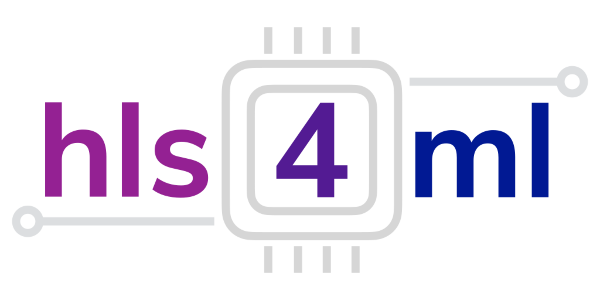

💡 **High-Level Synthesis for Machine Learning (hls4ml)** es una biblioteca de código abierto diseñada para convertir modelos de aprendizaje automático en descripciones de hardware optimizadas para su implementación en FPGAs 

**Características de hls4ml:** 

- Convierte modelos de Keras, TensorFlow, PyTorch, y ONNX en proyectos HLS (High-Level Synthesis).

- Usa herramientas como Xilinx Vitis HLS y Intel HLS Compiler para generar código en C++ optimizado para hardware.

- Permite reducir la latencia y el consumo de energía, mejorando la eficiencia en implementaciones de IA en edge computing.

- Soporta técnicas de cuantización y pruning para reducir el tamaño del modelo sin afectar significativamente su precisión.

**Aplicaciones de hls4ml:**

- Procesamiento en tiempo real en sistemas embebidos.

- Implementación de redes neuronales en hardware de baja potencia.

- Aceleración de modelos de IA en aplicaciones como física de partículas, visión artificial y robótica.


Para más información:

- GitHub: https://github.com/fastmachinelearning/hls4ml

- Web site: https://fastmachinelearning.org/hls4ml/

---

### Librerías

In [1]:
import os
import numpy as np
import tensorflow as tf 
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from qkeras import *
from qkeras import QActivation
from qkeras import QDense, QConv2DBatchnorm
import hls4ml
import matplotlib.pyplot as plt


### Path a Vitis HLS


Como paso inicial se debe especificar el directorio de instalación de Vivado HLS o Vitis HLS. 

In [13]:
# Path donde se encuentra instalado Vitis HLS!! 

os.environ['PATH'] = 'Volumes/denise_apfs/Xilinx/Vitis_HLS/2024.1/bin:' + os.environ['PATH']

# # Para MÁQUINA VIRTUAL!
# os.environ['PATH'] = '/tools/Xilinx/Vitis_HLS/2022.2/bin/vitis_hls:' + os.environ['PATH']

# os.environ['PATH']


### Carga del modelo (.h5)

Carga del modelo pre-entrenado y guardado en formato **.h5**. 

Para este laboratorio, el modelo fue generado en el **lab03**.

In [9]:

from qkeras.utils import _add_supported_quantized_objects
co = {}
_add_supported_quantized_objects(co)

os.getcwd()

model = load_model('./models/MNIST_bin_QAT_KD_st.h5', custom_objects=co)
    
# Resumen del modelo
model.summary()


/Users/denisegayet/.venv_py39_test/lib/python3.9/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer LecunUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model: "quantizedModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_22 (Flatten)        (None, 784)               0         
                                                                 
 fc3 (QDense)                (None, 5)                 3925      
                                                                 
 relu3 (QActivation)         (None, 5)                 0         
                                                                 
 dropout_18 (Dropout)        (None, 5)                 0         
                                                                 
 output (QDense)             (None, 2)                 12        
                                                                 
 softmax (Activation)        (None, 2)                 0         
                                                                 
Total params: 3937 (15.38 KB)
Trainable params: 3937

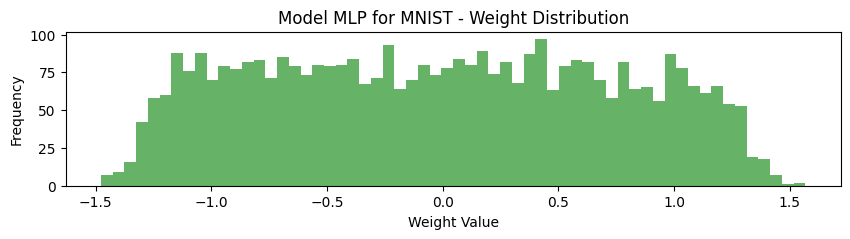

In [10]:
# Weight distribution

weights = np.concatenate([w.flatten() for w in model.get_weights()])

plt.figure(figsize=(10,2))
plt.hist(weights, bins=60, color='green', alpha=0.6)
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.title("Model MLP for MNIST - Weight Distribution")
plt.show()


### hls4ml 

💡 Arbitrary precision reference: https://docs.amd.com/r/2022.2-English/ug1399-vitis-hls/Fixed-Point-Identifier-Summary?tocId=jgeN4rPFF_M6nxbDn1H5HA

In [11]:

hls_config = hls4ml.utils.config_from_keras_model(model, granularity='name')

import plotting

print("-----------------------------------")
plotting.print_dict(hls_config)
print("-----------------------------------")




Interpreting Sequential
Topology:
Layer name: flatten_22_input, layer type: InputLayer, input shapes: [[None, 28, 28]], output shape: [None, 28, 28]
Layer name: flatten_22, layer type: Reshape, input shapes: [[None, 28, 28]], output shape: [None, 784]
Layer name: fc3, layer type: QDense, input shapes: [[None, 784]], output shape: [None, 5]
Layer name: relu3, layer type: Activation, input shapes: [[None, 5]], output shape: [None, 5]
Layer name: output, layer type: QDense, input shapes: [[None, 5]], output shape: [None, 2]
Layer name: softmax, layer type: Softmax, input shapes: [[None, 2]], output shape: [None, 2]
-----------------------------------
Model
  Precision:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  flatten_22_input
    Trace:           False
    Precision
      result:        fixed<16,6>
  flatten_22
    Trace:           False
    Precision
      result:        fixed<16,6>
  fc

In [12]:
from hls4ml.model.profiling import numerical, get_ymodel_keras

# the name of the different layers could be different!! 

# hls_config['LayerName']['flatten_22_input']['Precision'] = 'ap_fixed<16, 6>'  
# hls_config['LayerName']['flatten_22']['Precision'] = 'ap_fixed<8, 2>'  

# hls_config['LayerName']['fc3']['Precision'] = 'ap_fixed<8, 2>'  

# hls_config['LayerName']['relu_input']['Precision'] = 'ap_fixed<8, 3>'
hls_config['LayerName']['softmax']['Strategy'] = 'Stable'

hls_config['Model']['Precision'] = 'ap_fixed<8,4>'



### hls4ml con Vitis HLS como backend

In [14]:
cfg = hls4ml.converters.create_config(backend='Vitis')

# cfg['IOType']     = 'io_stream'   # Must set this if using CNNs!
cfg['HLSConfig']  = hls_config      # HLS configuraiton
cfg['KerasModel'] = model           # Keras model to be converted
cfg['OutputDir']  = 'hlsPrj/'       # Project name
cfg['Part'] = 'xc7z020clg484-1'     # PYNQ-Z1 or Zedboard: xc7z020clg484-1  ARTIX-7 xc7a35tcsg325-1  # MPSoC xczu4eg-sfvc784-2-e  xczu3eg-sfvc784-1-e


hls_model = hls4ml.converters.keras_to_hls(cfg)

hls_model.compile()

Interpreting Sequential
Topology:
Layer name: flatten_22_input, layer type: InputLayer, input shapes: [[None, 28, 28]], output shape: [None, 28, 28]
Layer name: flatten_22, layer type: Reshape, input shapes: [[None, 28, 28]], output shape: [None, 784]
Layer name: fc3, layer type: QDense, input shapes: [[None, 784]], output shape: [None, 5]
Layer name: relu3, layer type: Activation, input shapes: [[None, 5]], output shape: [None, 5]
Layer name: output, layer type: QDense, input shapes: [[None, 5]], output shape: [None, 2]
Layer name: softmax, layer type: Softmax, input shapes: [[None, 2]], output shape: [None, 2]
Creating HLS model
Writing HLS project


/Users/denisegayet/.venv_py39_test/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Done


firmware/myproject.cpp:1:10: fatal error: 'iostream' file not found
    1 | #include <iostream>
      |          ^~~~~~~~~~
1 error generated.
In file included from myproject_bridge.cpp:4:
In file included from ./firmware/myproject.h:4:
In file included from firmware/ap_types/ap_fixed.h:20:
firmware/ap_types/ap_common.h:130:10: fatal error: 'iostream' file not found
  130 | #include <iostream>
      |          ^~~~~~~~~~
1 error generated.
clang++: error: no such file or directory: 'myproject.o'
clang++: error: no such file or directory: 'myproject_bridge.o'
clang++: error: no input files


OSError: dlopen(hlsPrj//firmware/myproject-EbAA4aD6.so, 0x0006): tried: 'hlsPrj//firmware/myproject-EbAA4aD6.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OShlsPrj//firmware/myproject-EbAA4aD6.so' (no such file), '/opt/homebrew/lib/hlsPrj//firmware/myproject-EbAA4aD6.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/hlsPrj//firmware/myproject-EbAA4aD6.so' (no such file), '/opt/homebrew/lib/hlsPrj//firmware/myproject-EbAA4aD6.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/hlsPrj//firmware/myproject-EbAA4aD6.so' (no such file), '/usr/lib/hlsPrj//firmware/myproject-EbAA4aD6.so' (no such file, not in dyld cache), 'hlsPrj//firmware/myproject-EbAA4aD6.so' (no such file), '/Users/denisegayet/Documents/Cursos/UNMDP/ml_fpga_unmdp/labs/lab5/hlsPrj/firmware/myproject-EbAA4aD6.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/denisegayet/Documents/Cursos/UNMDP/ml_fpga_unmdp/labs/lab5/hlsPrj/firmware/myproject-EbAA4aD6.so' 

In [ ]:
hls_model.build(csim=False, export=False)

----

#### 📝 Ejercicio

- Realizar el proceso de síntesis para distintos modelos con diferentes técnicas de compresión y efectuar una comparación de los resultados obtenidos (latencia y utilización de recursos). ¿Qué conclusiones puede sacar al vincular el hardware generado con la técnica de compresión empleada? Considerar MNIST o Fashion dataset, empleando MLP como arquitectura (sin _flatten_ en la primera capa). Considere:
    
    - Pruning + quantization ( 8 bits)
    
    - Quantization (16 bits)

    - Knowledge distillation 
